In [78]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np

In [79]:
model = pybamm.lithium_ion.SPMe()
sim = pybamm.Simulation(model)
sim.solve([0, 3600])

# Accessing solution variables

In [80]:
# Extract the solution object by:
solution = sim.solution

# or
solution = sim.solve([0, 3600])

In [81]:
t = solution["Time [s]"]
V = solution["Voltage [V]"]

In [82]:
# Check whole variable values
V.entries

array([3.77057396, 3.77055358, 3.77053333, 3.7704931 , 3.77041403,
       3.7702603 , 3.76997849, 3.76971335, 3.76923473, 3.76879676,
       3.76839135, 3.76763934, 3.76696517, 3.7657705 , 3.76482861,
       3.76396994, 3.76317298, 3.76242499, 3.76105167, 3.75980242,
       3.75865012, 3.75758225, 3.75659013, 3.75479647, 3.7532074 ,
       3.75177811, 3.75047724, 3.74928148, 3.74817179, 3.74713337,
       3.74522275, 3.74364749, 3.74187167, 3.74036101, 3.73891052,
       3.73750368, 3.73613075, 3.73478468, 3.73346097, 3.73086618,
       3.7283324 , 3.72584895, 3.7210167 , 3.71687343, 3.7128573 ,
       3.70897172, 3.70521899, 3.70159986, 3.69476089, 3.68844401,
       3.68262899, 3.67728754, 3.6723848 , 3.66372342, 3.65617236,
       3.63840595, 3.59767151, 3.48863759, 3.17213165])

In [83]:
# Check whole variable values
t.entries

array([0.00000000e+00, 1.23792596e-02, 2.47585193e-02, 4.95170385e-02,
       9.90340771e-02, 1.98068154e-01, 3.96136308e-01, 5.94204462e-01,
       9.90340771e-01, 1.38647708e+00, 1.78261339e+00, 2.57488600e+00,
       3.36715862e+00, 4.95170385e+00, 6.37779456e+00, 7.80388527e+00,
       9.22997598e+00, 1.06560667e+01, 1.35082481e+01, 1.63604295e+01,
       1.92126109e+01, 2.20647924e+01, 2.49169738e+01, 3.06213366e+01,
       3.63256995e+01, 4.20300623e+01, 4.77344251e+01, 5.34387880e+01,
       5.91431508e+01, 6.48475137e+01, 7.62562393e+01, 8.65240924e+01,
       9.89736408e+01, 1.10178234e+02, 1.21382828e+02, 1.32587421e+02,
       1.43792015e+02, 1.54996608e+02, 1.66201202e+02, 1.88610389e+02,
       2.11019576e+02, 2.33428763e+02, 2.78247137e+02, 3.17930983e+02,
       3.57614829e+02, 3.97298675e+02, 4.36982521e+02, 4.76666368e+02,
       5.56034060e+02, 6.35401752e+02, 7.14769445e+02, 7.94137137e+02,
       8.73504829e+02, 1.03224021e+03, 1.19097560e+03, 1.50844637e+03,
      

In [84]:
# Check the variable values at specific times
V([0, 400, 780, 1236])  # times in seconds

array([3.77057396, 3.70871203, 3.67820577, 3.65411564])

# Observing custom variables from the solution

In [85]:
# View all OUTPUT variables in the model.
model.variables

{'Time [s]': Time(-0x59648d35823ec787, time, children=[], domains={}),
 'Time [min]': Multiplication(-0xd73b69ca676fc3, *, children=['0.016666666666666666', 'time'], domains={}),
 'Time [h]': Multiplication(-0x47bc7bcd345e736, *, children=['0.0002777777777777778', 'time'], domains={}),
 'x [m]': SpatialVariable(-0x3032a18bcef2f326, x, children=[], domains={'primary': ['negative electrode', 'separator', 'positive electrode'], 'secondary': ['current collector']}),
 'x_n [m]': SpatialVariable(-0x78d7077fab9e7bbe, x_n, children=[], domains={'primary': ['negative electrode'], 'secondary': ['current collector']}),
 'x_s [m]': SpatialVariable(-0x5f08e577a67a9a03, x_s, children=[], domains={'primary': ['separator'], 'secondary': ['current collector']}),
 'x_p [m]': SpatialVariable(0x46507d609c3d6103, x_p, children=[], domains={'primary': ['positive electrode'], 'secondary': ['current collector']}),
 'r_n [m]': SpatialVariable(0x40984eb4d9fca031, r_n, children=[], domains={'primary': ['negative

In [86]:
model.variables.search("Voltage")

Results for 'Voltage': ['Local voltage [V]', 'Voltage expression [V]', 'Terminal voltage [V]', 'Voltage [V]', 'Surface open-circuit voltage [V]', 'Bulk open-circuit voltage [V]', 'Battery open-circuit voltage [V]', 'Battery voltage [V]']


Text(0, 0.5, 'Conductance [S]')

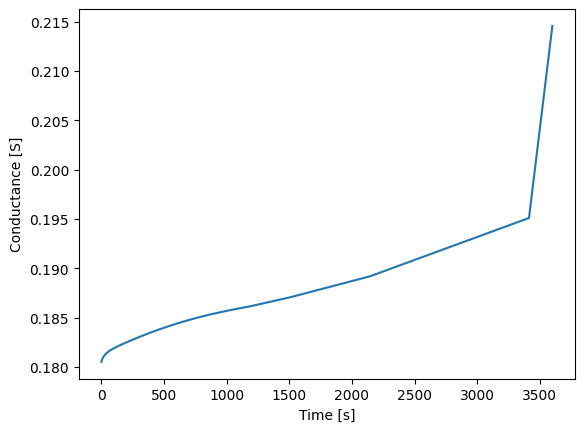

In [87]:
# Calculate extra variable that are not included in the model output. For example, conductance = current / voltage.
t = solution["Time [s]"].entries
conductance = solution["Current [A]"].entries / solution["Voltage [V]"].entries

plt.plot(t, conductance)
plt.xlabel("Time [s]")
plt.ylabel("Conductance [S]")

In [88]:
# PyBaMM’s solver uses adaptive time stepping, so the saved solver times are uneven. To overview the time steps:
t = solution["Time [s]"].entries
dt = np.diff(t)

print(dt)
print("Number of saved points:", len(t))
print("Min dt [s]:", dt.min())
print("Max dt [s]:", dt.max())
print("Mean dt [s]:", dt.mean())

[1.23792596e-02 1.23792596e-02 2.47585193e-02 4.95170385e-02
 9.90340771e-02 1.98068154e-01 1.98068154e-01 3.96136308e-01
 3.96136308e-01 3.96136308e-01 7.92272616e-01 7.92272616e-01
 1.58454523e+00 1.42609071e+00 1.42609071e+00 1.42609071e+00
 1.42609071e+00 2.85218142e+00 2.85218142e+00 2.85218142e+00
 2.85218142e+00 2.85218142e+00 5.70436284e+00 5.70436284e+00
 5.70436284e+00 5.70436284e+00 5.70436284e+00 5.70436284e+00
 5.70436284e+00 1.14087257e+01 1.02678531e+01 1.24495483e+01
 1.12045935e+01 1.12045935e+01 1.12045935e+01 1.12045935e+01
 1.12045935e+01 1.12045935e+01 2.24091870e+01 2.24091870e+01
 2.24091870e+01 4.48183740e+01 3.96838462e+01 3.96838462e+01
 3.96838462e+01 3.96838462e+01 3.96838462e+01 7.93676923e+01
 7.93676923e+01 7.93676923e+01 7.93676923e+01 7.93676923e+01
 1.58735385e+02 1.58735385e+02 3.17470769e+02 6.34941538e+02
 1.26988308e+03 1.86729017e+02]
Number of saved points: 59
Min dt [s]: 0.012379259631352576
Max dt [s]: 1269.8830768063908
Mean dt [s]: 62.0689655

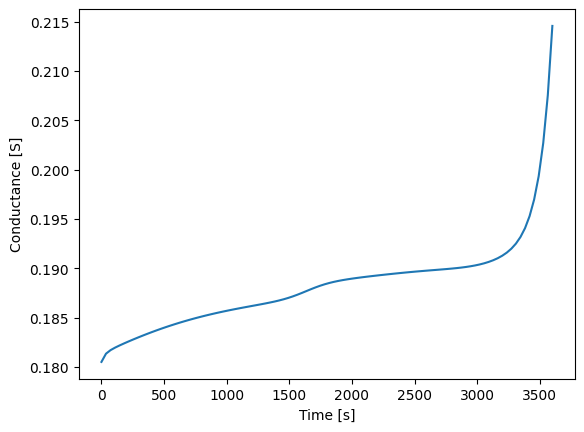

In [89]:
# Plot a smoother curve by interpolating the solution.
t = np.linspace(0, solution.t[-1], 100)     # Create a new time grid with 100 steps.

current = solution["Current [A]"](t)
voltage = solution["Voltage [V]"](t)

conductance = current / voltage

plt.plot(t, conductance)
plt.xlabel("Time [s]")
plt.ylabel("Conductance [S]")
plt.show()

# Saving the simulation and output data

## Saving the whole simulation

In [90]:
# Save the simulation results for analyzing later w/o re-simulating. The file is saved in the root directory as "SPMe.pkl".
sim.save("SPMe.pkl")

In [ ]:
# Load and plot the stored simulation
sim2 = pybamm.load("SPMe.pkl")
sim2.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

## Saving the solution

In [96]:
# Alternatively, can just save the solution.
sol = sim.solution
sol.save("SPMe_sol.pkl")

In [100]:
# Load and plot the saved solution.
sol2 = pybamm.load("SPMe_sol.pkl")
sol2.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

## Saving specific data / variables

In [ ]:
# Another way is to only save specific data / variables in .pkl format.
sol.save_data("sol_data.pkl", ["Current [A]", "Voltage [V]"])

In [ ]:
# Or save it in .csv format.
sol.save_data("sol_data.csv", ["Current [A]", "Voltage [V]"], to_format="csv")

# Or in or .mat format. Note that matlab needs names without spaces
sol.save_data(
    "sol_data.mat",
    ["Current [A]", "Voltage [V]"],
    to_format="matlab",
    short_names={"Current [A]": "I", "Voltage [V]": "V"},
)